# Random Forest Final Test Prediction Analysis

This notebook freezes the Optuna-selected Random Forest hyperparameters, fits the model once on the outer training split, and analyzes predictions on the untouched outer test set.

In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from classical_ml.random_forest import (
    RandomForestDataBuilder,
    RandomForestExperimentConfig,
    RandomForestHoldoutSplitter,
    RandomForestTrainer,
    compute_regression_metrics,
)
from utils.chemistry_encoding import ChemistryEncoder
from utils.sequence_encoding import SequenceEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Frozen Configuration

In [3]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

config = RandomForestExperimentConfig(
    target_column="Inhibition",
    strict_cleaning=True,
    add_mrna=True,
    use_normalized_conditions=False,
    outer_test_size=0.33,
    n_splits=3,
    leak_n=30,
    random_state=42,
    n_estimators=500,
    max_depth=None,
    min_samples_split=7,
    min_samples_leaf=1,
    max_features=0.3,
    n_jobs=-1,
)

config

RandomForestExperimentConfig(target_column='Inhibition', target_len=25, strict_cleaning=True, add_mrna=True, fetch_missing_mrna=True, use_normalized_conditions=False, n_splits=3, leak_n=30, outer_test_size=0.33, random_state=42, n_estimators=500, max_depth=None, min_samples_split=7, min_samples_leaf=1, max_features=0.3, n_jobs=-1, tuning_n_iter=20, tuning_scoring='neg_mean_absolute_error', optuna_n_trials=20)

## Build Data

In [4]:
builder = RandomForestDataBuilder(config)
prepared = builder.build_from_merged_sources(cmsirna_path, historic_path)

print("Enriched dataframe shape:", prepared.enriched_df.shape)
print("Feature matrix shape:", prepared.X.shape)
print("Target shape:", prepared.y.shape)
print("Unique genes:", len(np.unique(prepared.groups)))

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

## Run Final Outer-Test Evaluation

This uses the proper outer holdout split. The final model is fit once on the outer training portion only using the frozen Optuna hyperparameters, and the outputs below describe performance on the untouched outer test set.

In [5]:
holdout_splitter = RandomForestHoldoutSplitter(config)
train_idx, test_idx = holdout_splitter.split(prepared.X, prepared.y, prepared.groups)

X_train = prepared.X[train_idx]
y_train = prepared.y[train_idx]
groups_train = prepared.groups[train_idx]
X_test = prepared.X[test_idx]
y_test = prepared.y[test_idx]
groups_test = prepared.groups[test_idx]

trainer = RandomForestTrainer(config)
trainer.fit(X_train, y_train)
y_test_pred = trainer.predict(X_test)

test_metric_values = compute_regression_metrics(y_test, y_test_pred)
test_metrics = pd.DataFrame([test_metric_values])
split_summary = pd.DataFrame([{
    "n_train": int(len(train_idx)),
    "n_test": int(len(test_idx)),
    "n_train_groups": int(len(np.unique(groups_train))),
    "n_test_groups": int(len(np.unique(groups_test))),
}])

test_metadata = prepared.enriched_df.iloc[test_idx].reset_index().rename(columns={"index": "source_index"}).copy()
test_metadata["patent_group"] = test_metadata.get("patent_ID", pd.Series(index=test_metadata.index, dtype=object)).fillna("HISTORIC_OR_UNKNOWN")
test_metadata["Authorization_status"] = test_metadata.get("Authorization_status", pd.Series(index=test_metadata.index, dtype=object)).fillna("UNKNOWN")
test_metadata["Title"] = test_metadata.get("Title", pd.Series(index=test_metadata.index, dtype=object)).fillna("HISTORIC_OR_UNKNOWN")

test_predictions = test_metadata.copy()
test_predictions["row_index"] = test_idx
test_predictions["group"] = groups_test
test_predictions["y_true"] = y_test
test_predictions["y_pred"] = y_test_pred
test_predictions["residual"] = test_predictions["y_true"] - test_predictions["y_pred"]
test_predictions["abs_error"] = test_predictions["residual"].abs()

split_summary

,n_train,n_test,n_train_groups,n_test_groups
0,26101,10864,36,18


In [6]:
{
    "n_estimators": config.n_estimators,
    "max_depth": config.max_depth,
    "min_samples_split": config.min_samples_split,
    "min_samples_leaf": config.min_samples_leaf,
    "max_features": config.max_features,
}

{'n_estimators': 500,
 'max_depth': None,
 'min_samples_split': 7,
 'min_samples_leaf': 1,
 'max_features': 0.3}

In [7]:
test_metrics

,pearson,spearman,rmse,mae
0,0.287733,0.335756,36.207205,28.724077


## Test Prediction Table

In [8]:
test_predictions[[
    "group",
    "Cell_Type",
    "Concentration_nM",
    "Time_of_administration_h",
    "patent_group",
    "y_true",
    "y_pred",
    "residual",
    "abs_error",
]].head(20)

,group,Cell_Type,Concentration_nM,Time_of_administration_h,patent_group,y_true,y_pred,residual,abs_error
0,CTNNB1,Hela,100.0,48.0,CN107365771B,88.00,60.101722,27.898278,27.898278
1,CTNNB1,Hela,100.0,48.0,CN107365771B,90.00,72.433192,17.566808,17.566808
2,CTNNB1,Hela,100.0,48.0,CN107365771B,90.00,60.362790,29.637210,29.637210
3,CTNNB1,Hela,100.0,48.0,CN107365771B,89.00,75.130802,13.869198,13.869198
4,CTNNB1,Hela,100.0,48.0,CN107365771B,87.00,72.840737,14.159263,14.159263
5,CTNNB1,Hela,100.0,48.0,CN107365771B,91.00,76.197347,14.802653,14.802653
6,CTNNB1,Hela,100.0,48.0,CN107365771B,62.00,57.781904,4.218096,4.218096
7,CTNNB1,Hep3B,10.0,24.0,WO2023003995A8,93.62,64.375922,29.244078,29.244078
8,CTNNB1,Hep3B,10.0,24.0,WO2023003995A8,92.55,52.075331,40.474669,40.474669
9,CTNNB1,Hep3B,10.0,24.0,WO2023003995A8,93.48,75.183620,18.296380,18.296380


## Overall Prediction Behavior

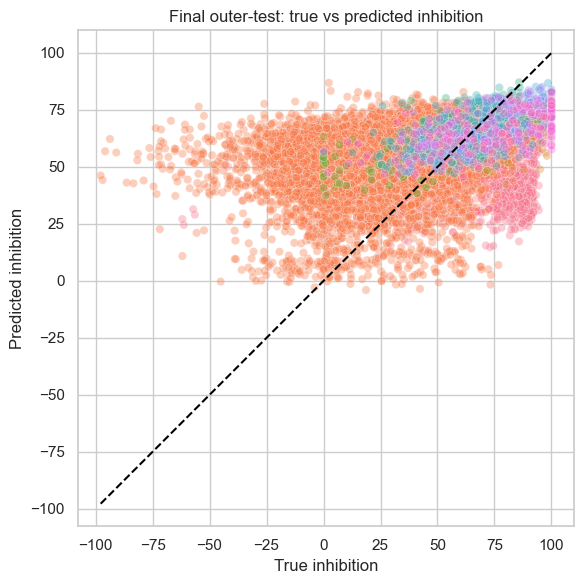

In [9]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=test_predictions, x="y_true", y="y_pred", alpha=0.35, hue="group", legend=False)
line_min = min(test_predictions["y_true"].min(), test_predictions["y_pred"].min())
line_max = max(test_predictions["y_true"].max(), test_predictions["y_pred"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.title("Final outer-test: true vs predicted inhibition")
plt.xlabel("True inhibition")
plt.ylabel("Predicted inhibition")
plt.tight_layout()

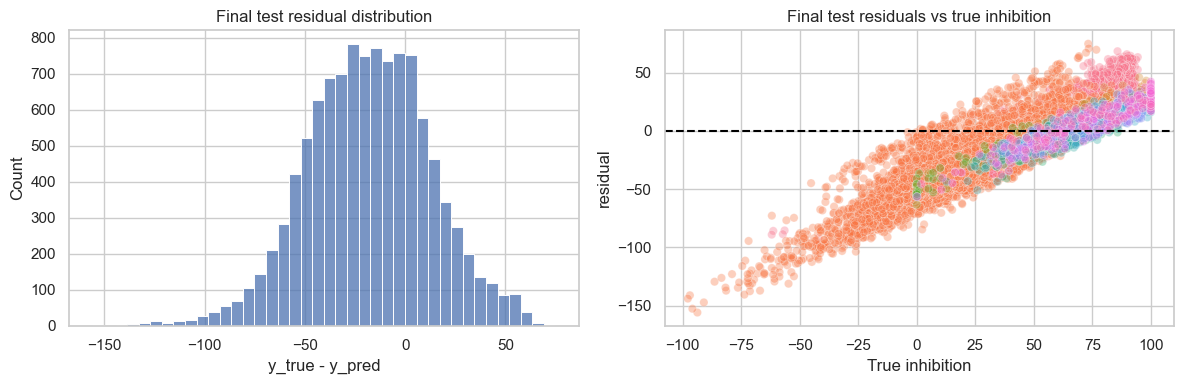

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(test_predictions["residual"], bins=40, ax=axes[0])
axes[0].set_title("Final test residual distribution")
axes[0].set_xlabel("y_true - y_pred")

sns.scatterplot(data=test_predictions, x="y_true", y="residual", alpha=0.35, hue="group", ax=axes[1], legend=False)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Final test residuals vs true inhibition")
axes[1].set_xlabel("True inhibition")

plt.tight_layout()

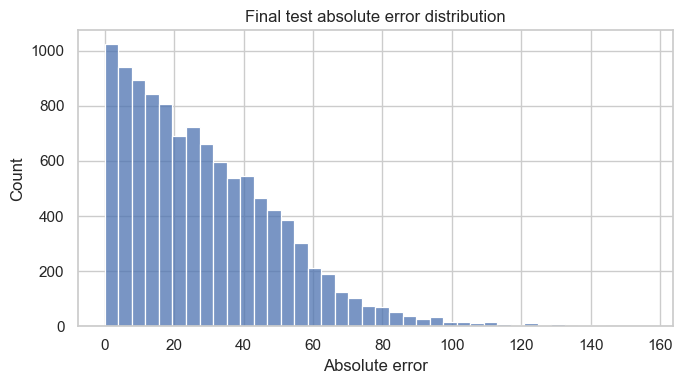

In [11]:
plt.figure(figsize=(7, 4))
sns.histplot(test_predictions["abs_error"], bins=40)
plt.title("Final test absolute error distribution")
plt.xlabel("Absolute error")
plt.tight_layout()

## Feature Importance

Random Forest feature importances show which input dimensions were most useful for split decisions in the final trained model. They do not tell us whether a feature increases or decreases inhibition, but they do show which parts of the input the forest relied on most.

In [12]:
seq_encoder = SequenceEncoder(prepared.enriched_df.copy(), target_len=config.target_len)
seq_symbols = list(seq_encoder.build_encoding_map().keys())

chem_encoder = ChemistryEncoder(prepared.enriched_df.copy(), target_len=config.target_len)
acid_symbols = list(chem_encoder.acid_map.keys())
sugar_symbols = list(chem_encoder.sugar_map.keys())
linker_symbols = list(chem_encoder.linker_map.keys())
cell_types = sorted(prepared.enriched_df["Cell_Type"].dropna().unique())

def matrix_feature_names(prefix, symbols, length):
    return [
        f"{prefix}_pos{pos}_{symbol}"
        for pos in range(1, length + 1)
        for symbol in symbols
    ]

feature_names = ["Concentration_log10_nM", "Time_of_administration_h"]
feature_names.extend([f"Cell_Type_{cell_type}" for cell_type in cell_types])
feature_names.extend(matrix_feature_names("Sense_Sequence", seq_symbols, config.target_len))
feature_names.extend(matrix_feature_names("Antisense_Sequence", seq_symbols, config.target_len))
feature_names.extend(matrix_feature_names("Sense_Acid", acid_symbols, config.target_len))
feature_names.extend(matrix_feature_names("Sense_Sugar", sugar_symbols, config.target_len))
feature_names.extend(matrix_feature_names("Sense_Linker", linker_symbols, config.target_len))
feature_names.extend(matrix_feature_names("Antisense_Acid", acid_symbols, config.target_len))
feature_names.extend(matrix_feature_names("Antisense_Sugar", sugar_symbols, config.target_len))
feature_names.extend(matrix_feature_names("Antisense_Linker", linker_symbols, config.target_len))
if "edit_distance" in prepared.enriched_df.columns and "target_site_pct" in prepared.enriched_df.columns:
    feature_names.extend(["edit_distance", "target_site_pct"])

assert len(feature_names) == prepared.X.shape[1], (len(feature_names), prepared.X.shape[1])
len(feature_names)

1425

In [35]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trainer.model.feature_importances_,
})
feature_importance_df["family"] = feature_importance_df["feature"].str.extract(r"^([^_]+(?:_[^_]+)?)")
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
feature_importance_df.head(25)

,feature,importance,family
0,Concentration_log10_nM,0.199031,Concentration_log10
1,target_site_pct,0.083705,target_site
2,Cell_Type_Hep3B,0.020675,Cell_Type
3,edit_distance,0.020524,edit_distance
4,Antisense_Sugar_pos7_Unmodified,0.014119,Antisense_Sugar
5,Antisense_Sugar_pos6_2'-OMe,0.013817,Antisense_Sugar
6,Cell_Type_Primary Cynomolgus Monkey Hepatocytes,0.011176,Cell_Type
7,Cell_Type_Primary human hepatocytes,0.010371,Cell_Type
8,Antisense_Sequence_pos10_A,0.008780,Antisense_Sequence
9,Time_of_administration_h,0.008127,Time_of


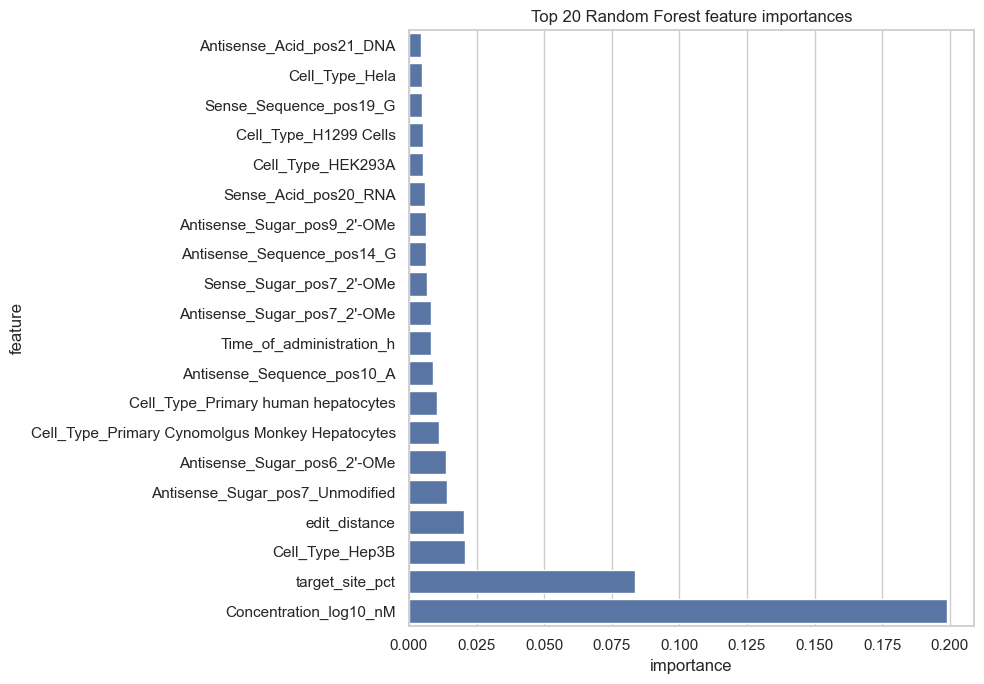

In [36]:
top_n = 20
plot_df = feature_importance_df.head(top_n).sort_values("importance", ascending=True)
plt.figure(figsize=(10, 7))
sns.barplot(data=plot_df, x="importance", y="feature")
plt.title(f"Top {top_n} Random Forest feature importances")
plt.tight_layout()

In [37]:
family_importance = feature_importance_df.groupby("family", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
family_importance

,family,importance
2,Antisense_Sequence,0.213731
5,Concentration_log10,0.199031
8,Sense_Sequence,0.184926
3,Antisense_Sugar,0.090041
12,target_site,0.083705
4,Cell_Type,0.080130
9,Sense_Sugar,0.060252
0,Antisense_Acid,0.024301
11,edit_distance,0.020524
1,Antisense_Linker,0.013619


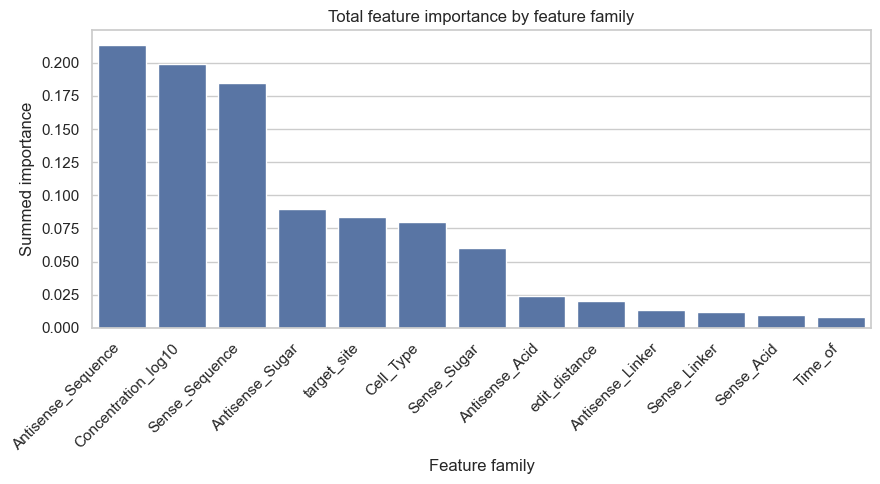

In [38]:
plt.figure(figsize=(9, 5))
sns.barplot(data=family_importance, x="family", y="importance")
plt.title("Total feature importance by feature family")
plt.xlabel("Feature family")
plt.ylabel("Summed importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Spearman By Experimental Slice

These tables look at ranking behavior in isolation for experimental subsets. They help us see whether the model preserves the relative ordering of potency better in some conditions than others.

In [57]:
def grouped_spearman(df, group_cols, min_samples=10):
    rows = []
    for keys, group_df in df.groupby(group_cols, dropna=False):
        if len(group_df) < min_samples:
            continue
        corr = spearmanr(group_df["y_true"], group_df["y_pred"], nan_policy="omit").statistic
        if pd.isna(corr):
            continue
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: value for col, value in zip(group_cols, keys)}
        row.update({
            "n_samples": len(group_df),
            "spearman": float(corr),
            "mae": float(group_df["abs_error"].mean()),
            "mean_true": float(group_df["y_true"].mean()),
            "mean_pred": float(group_df["y_pred"].mean()),
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["spearman", "mae"], ascending=[True, False]).reset_index(drop=True)

spearman_by_concentration = grouped_spearman(test_predictions, ["Concentration_nM"], min_samples=20)
spearman_by_concentration_gene = grouped_spearman(test_predictions, ["Concentration_nM", "group"], min_samples=10)
spearman_by_concentration_patent = grouped_spearman(test_predictions, ["Concentration_nM", "patent_group"], min_samples=10)

spearman_by_concentration.sort_values(["spearman", "mae"], ascending=[True, False])

,Concentration_nM,n_samples,spearman,mae,mean_true,mean_pred
0,1.0,2279,-0.002672,30.761343,33.404581,46.262641
1,0.1,1754,0.091725,36.759150,19.496425,45.497641
2,0.5,448,0.129133,44.078517,2.854978,46.899553
3,10.0,2619,0.222069,27.416554,41.854708,60.139543
4,20.0,135,0.241489,28.990034,26.283778,54.205486
5,5.0,449,0.264921,33.241224,18.791759,50.920695
6,100.0,268,0.304811,35.173431,28.591835,59.820948
7,50.0,2868,0.524252,19.676222,49.249616,60.459248
8,200.0,44,0.610828,27.948642,87.227273,60.244453


In [58]:
print("Worst final-test Concentration + Gene combinations by Spearman")
spearman_by_concentration_gene.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

Worst final-test Concentration + Gene combinations by Spearman


,Concentration_nM,group,n_samples,spearman,mae,mean_true,mean_pred
0,0.1,CTNNB1,426,-0.303240,30.121791,54.026854,45.198634
1,1.0,CTNNB1,426,-0.208089,32.306683,68.317160,42.999417
2,0.5,PNPLA3,448,0.129133,44.078517,2.854978,46.899553
3,1.0,PNPLA3,1853,0.135719,30.406073,25.378268,47.012848
4,100.0,PNPLA3,180,0.228248,41.085229,20.005000,61.039542
5,20.0,PNPLA3,135,0.241489,28.990034,26.283778,54.205486
6,0.1,PNPLA3,1328,0.255307,38.888303,8.419646,45.593557
7,10.0,CTNNB1,426,0.261451,22.607857,75.662582,58.835000
8,5.0,PNPLA3,449,0.264921,33.241224,18.791759,50.920695
9,10.0,PNPLA3,2193,0.291988,28.350665,35.287378,60.392956


In [59]:
print("Worst final-test Concentration + Patent combinations by Spearman")
spearman_by_concentration_patent.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

Worst final-test Concentration + Patent combinations by Spearman


,Concentration_nM,patent_group,n_samples,spearman,mae,mean_true,mean_pred
0,0.1,WO2023003995A8,426,-0.303240,30.121791,54.026854,45.198634
1,1.0,WO2023003995A8,426,-0.208089,32.306683,68.317160,42.999417
2,1.0,WO2022256395A1,691,0.116223,25.396159,32.018842,40.781710
3,0.5,WO2023034937A1,448,0.129133,44.078517,2.854978,46.899553
4,10.0,US20220117999A1,337,0.130644,42.482278,25.612404,65.068642
5,100.0,CN115176007A,180,0.228248,41.085229,20.005000,61.039542
6,0.1,CN115176007A,989,0.238822,34.815814,9.060880,42.031170
7,20.0,US20220117999A1,135,0.241489,28.990034,26.283778,54.205486
8,50.0,WO2023034937A1,450,0.247585,37.443398,19.514667,56.137976
9,10.0,WO2023003995A8,426,0.261451,22.607857,75.662582,58.835000


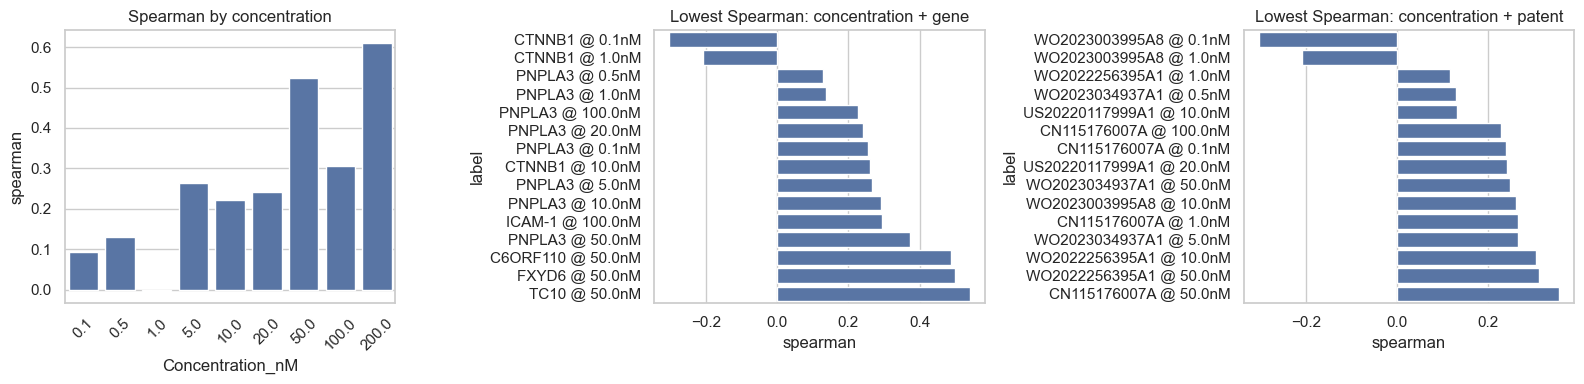

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=spearman_by_concentration.sort_values("Concentration_nM"), x="Concentration_nM", y="spearman", ax=axes[0])
axes[0].set_title("Spearman by concentration")
axes[0].tick_params(axis="x", rotation=45)

top_bad_gene = spearman_by_concentration_gene.head(min(15, len(spearman_by_concentration_gene))).copy()
top_bad_gene["label"] = top_bad_gene["group"] + " @ " + top_bad_gene["Concentration_nM"].astype(str) + "nM"
sns.barplot(data=top_bad_gene, x="spearman", y="label", ax=axes[1])
axes[1].set_title("Lowest Spearman: concentration + gene")

top_bad_patent = spearman_by_concentration_patent.head(min(15, len(spearman_by_concentration_patent))).copy()
top_bad_patent["label"] = top_bad_patent["patent_group"].astype(str).str.slice(0, 18) + " @ " + top_bad_patent["Concentration_nM"].astype(str) + "nM"
sns.barplot(data=top_bad_patent, x="spearman", y="label", ax=axes[2])
axes[2].set_title("Lowest Spearman: concentration + patent")

plt.tight_layout()

## Experimental Features Defining Issues

These summaries highlight which experimental conditions are most associated with poor errors or weak ranking on the final outer test set.

In [61]:
def issue_summary(df, group_col, min_samples=20):
    rows = []
    for value, group_df in df.groupby(group_col, dropna=False):
        if len(group_df) < min_samples:
            continue
        corr = spearmanr(group_df["y_true"], group_df["y_pred"], nan_policy="omit").statistic
        rows.append({
            group_col: value,
            "n_samples": len(group_df),
            "mae": float(group_df["abs_error"].mean()),
            "rmse": float(np.sqrt(np.mean(np.square(group_df["residual"])))),
            "spearman": float(corr) if not pd.isna(corr) else np.nan,
            "mean_true": float(group_df["y_true"].mean()),
            "mean_pred": float(group_df["y_pred"].mean()),
        })
    return pd.DataFrame(rows).sort_values(["spearman", "mae"], ascending=[True, False]).reset_index(drop=True)

issue_by_cell_type = issue_summary(test_predictions, "Cell_Type", min_samples=30)
issue_by_concentration = issue_summary(test_predictions, "Concentration_nM", min_samples=20)
issue_by_time = issue_summary(test_predictions, "Time_of_administration_h", min_samples=20)
issue_by_patent = issue_summary(test_predictions, "patent_group", min_samples=20)
issue_by_authorization = issue_summary(test_predictions, "Authorization_status", min_samples=20)

issue_by_cell_type.sort_values(["spearman", "mae"], ascending=[True, False])

,Cell_Type,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,Hep3B,4672,27.973432,34.688509,0.134866,41.093806,52.347286
1,Primary mouse hepatocytes,180,65.763779,75.755305,0.147947,-1.009278,58.795876
2,T24 Cells,40,24.649884,29.964255,0.293485,28.125000,50.147654
3,HepG2,1033,21.721649,29.853403,0.299984,37.273640,51.918911
4,COS7,2402,33.002373,38.206586,0.443710,18.961074,50.329361
5,Primary Cynomolgus Monkey Hepatocytes,1582,33.668925,42.262876,0.466085,26.915759,57.640159
6,H1299 Cells,863,13.086599,16.303993,0.569005,69.083893,66.578666
7,HeLa Cells,44,27.948642,28.896521,0.610828,87.227273,60.244453
8,HEK293 Cells,41,22.511987,27.151973,0.698191,57.066138,62.540045


In [62]:
issue_by_concentration.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,1.0,2279,30.761343,37.298682,-0.002672,33.404581,46.262641
1,0.1,1754,36.759150,43.604845,0.091725,19.496425,45.497641
2,0.5,448,44.078517,46.612141,0.129133,2.854978,46.899553
3,10.0,2619,27.416554,36.382114,0.222069,41.854708,60.139543
4,20.0,135,28.990034,34.556621,0.241489,26.283778,54.205486
5,5.0,449,33.241224,37.798079,0.264921,18.791759,50.920695
6,100.0,268,35.173431,40.667015,0.304811,28.591835,59.820948
7,50.0,2868,19.676222,26.500010,0.524252,49.249616,60.459248
8,200.0,44,27.948642,28.896521,0.610828,87.227273,60.244453


In [63]:
issue_by_time.sort_values(["spearman", "mae"], ascending=[True, False])

,Time_of_administration_h,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,24.0,8563,28.833905,36.654041,0.239884,35.300604,53.052380
1,72.0,1347,38.249454,42.500575,0.284303,13.732836,51.326266
2,4.0,40,24.649884,29.964255,0.293485,28.125000,50.147654
3,48.0,914,13.835478,17.147138,0.518581,70.081400,66.283362


In [64]:
issue_by_patent.sort_values(["spearman", "mae"], ascending=[True, False])

,patent_group,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,WO2023003995A8,1278,28.345444,33.099974,0.052349,66.002199,49.011017
1,WO2022256395A1,2067,22.890309,31.346984,0.280593,36.786589,50.777857
2,WO2023034937A1,1347,38.249454,42.500575,0.284303,13.732836,51.326266
3,US20220117999A1,811,43.700381,53.635875,0.316442,17.755573,59.463982
4,CN115176007A,4366,29.088636,36.163798,0.477818,28.664888,54.032109
5,HISTORIC_OR_UNKNOWN,988,14.607755,18.339022,0.568891,67.734931,65.463758


In [65]:
issue_by_authorization.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Authorization_status,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,Substantive Examination,1278,28.345444,33.099974,0.052349,66.002199,49.011017
1,Unknown Status,8598,30.402469,38.144046,0.379732,27.295148,53.349458
2,UNKNOWN,988,14.607755,18.339022,0.568891,67.734931,65.463758


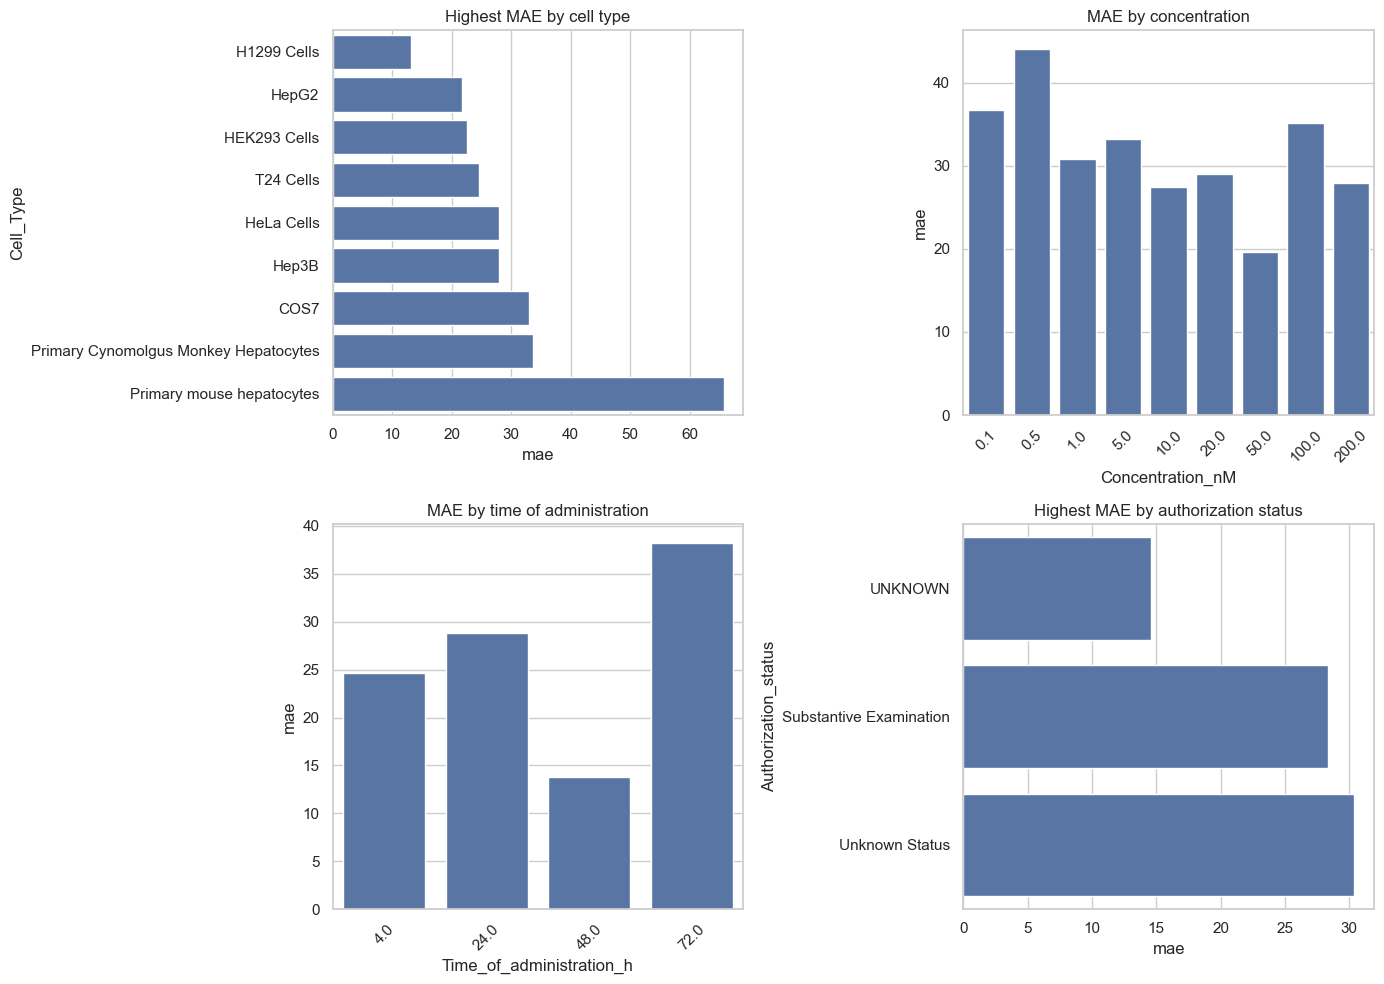

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_cell = issue_by_cell_type.head(min(12, len(issue_by_cell_type))).sort_values("mae", ascending=True)
sns.barplot(data=plot_cell, x="mae", y="Cell_Type", ax=axes[0, 0])
axes[0, 0].set_title("Highest MAE by cell type")

plot_conc = issue_by_concentration.sort_values("Concentration_nM").copy()
sns.barplot(data=plot_conc, x="Concentration_nM", y="mae", ax=axes[0, 1])
axes[0, 1].set_title("MAE by concentration")
axes[0, 1].tick_params(axis="x", rotation=45)

plot_time = issue_by_time.sort_values("Time_of_administration_h").copy()
sns.barplot(data=plot_time, x="Time_of_administration_h", y="mae", ax=axes[1, 0])
axes[1, 0].set_title("MAE by time of administration")
axes[1, 0].tick_params(axis="x", rotation=45)

plot_auth = issue_by_authorization.head(min(10, len(issue_by_authorization))).sort_values("mae", ascending=True)
sns.barplot(data=plot_auth, x="mae", y="Authorization_status", ax=axes[1, 1])
axes[1, 1].set_title("Highest MAE by authorization status")

plt.tight_layout()

## Gene-Level Test Consequences

In [67]:
gene_test_summary = test_predictions.groupby("group").agg(
    n_samples=("y_true", "size"),
    y_true_mean=("y_true", "mean"),
    y_pred_mean=("y_pred", "mean"),
    mae=("abs_error", "mean"),
    rmse=("residual", lambda series: np.sqrt(np.mean(np.square(series)))),
).sort_values("mae", ascending=False)
gene_test_summary.head(20)

,n_samples,y_true_mean,y_pred_mean,mae,rmse
group,,,,,
DBI,9,26.126457,47.926777,31.170875,34.355756
PNPLA3,8591,27.247897,53.337654,30.413023,38.155625
CTNNB1,1285,66.107245,49.113562,28.286092,33.040270
LAMIN A,44,87.227273,60.244453,27.948642,28.896521
GAPDH,20,62.592014,65.274695,25.333944,29.761072
ICAM-1,40,28.125000,50.147654,24.649884,29.964255
MMP7,113,77.827434,66.379108,21.351951,24.160900
FXYD6,72,72.044444,66.056686,14.970104,17.448775
UBE2H,70,78.122857,69.561706,14.094417,15.998571


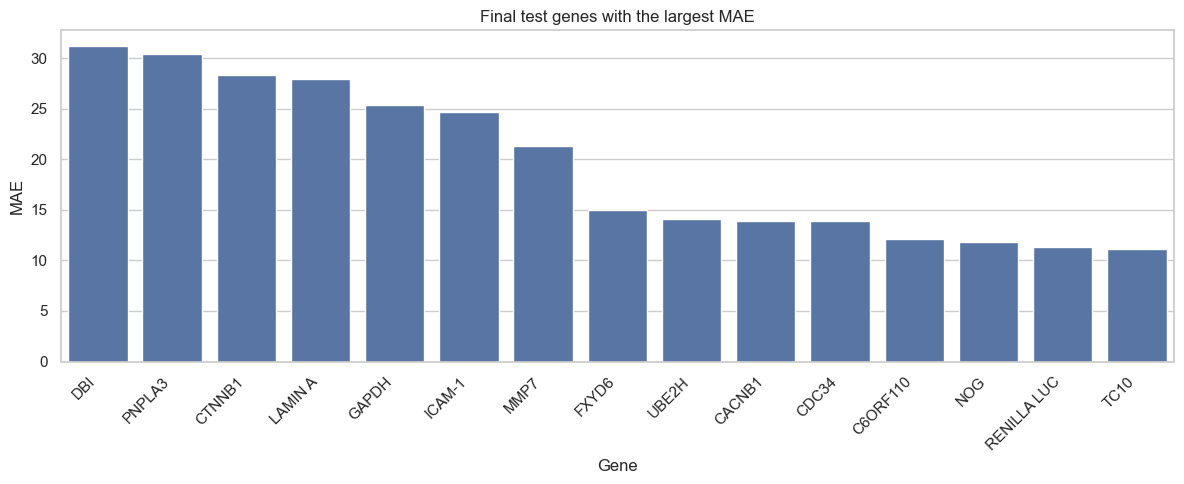

In [68]:
top_gene_count = min(15, len(gene_test_summary))
plot_df = gene_test_summary.head(top_gene_count).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="group", y="mae")
plt.title("Final test genes with the largest MAE")
plt.xlabel("Gene")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

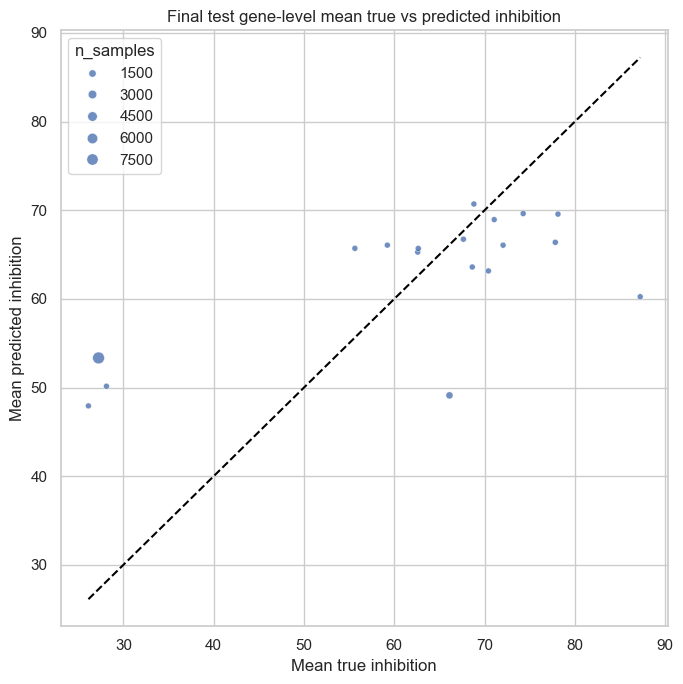

In [69]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=gene_test_summary.reset_index(), x="y_true_mean", y="y_pred_mean", size="n_samples", alpha=0.8)
line_min = min(gene_test_summary["y_true_mean"].min(), gene_test_summary["y_pred_mean"].min())
line_max = max(gene_test_summary["y_true_mean"].max(), gene_test_summary["y_pred_mean"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.title("Final test gene-level mean true vs predicted inhibition")
plt.xlabel("Mean true inhibition")
plt.ylabel("Mean predicted inhibition")
plt.tight_layout()

## Interpretation Notes

- These are the final outer-test results, so they should be treated as the main unbiased evaluation for this selected RF model.
- Overall generalization is only moderate here: Pearson is about `0.29`, Spearman about `0.34`, and MAE about `28.7`. That means the RF baseline is learning real signal, but it is still far from a strong predictive model on unseen test groups.
- The model is relying heavily on `Concentration_log10_nM`, `target_site_pct`, `Cell_Type`, `edit_distance`, and several antisense/sense sequence and sugar-modification positions. That is biologically plausible, so the model is not obviously focusing on meaningless features.
- The weakest concentration regimes on the final test set are `0.1 nM`, `0.5 nM`, and `1 nM`, all with very poor or near-zero Spearman and high MAE. These low-dose regimes are strong candidates for being noisy, weak-signal, or inconsistently measured.
- Concentrations around `50 nM` behave much better than the very low-dose conditions, which suggests the model is learning more reliably in stronger-signal assay regimes.
- Potentially problematic cell contexts on the final outer test include `Primary mouse hepatocytes`, `Primary Cynomolgus Monkey Hepatocytes`, `COS7`, and `Hep3B`, all of which show high error and weak-to-moderate ranking. These should be reviewed as possible assay/domain-shift sources before CNN training.
- Potentially problematic patent groups on the final outer test include `US20220117999A1`, `WO2023034937A1`, and especially `WO2023003995A8`, which shows very weak ranking despite a large sample count. These are strong candidates for protocol heterogeneity or label inconsistency.
- At the gene level, `PNPLA3` and `CTNNB1` stand out as difficult targets with large mean shifts and high MAE, while tiny groups like `DBI` should be treated cautiously because they may be too small for stable conclusions.
- Important caution: these subsets should be treated as review candidates, not automatic removals. A subset is a stronger poisoning candidate only if it is large enough to matter and it also looks poor in the all-data investigation notebook, not just here on the final test split.
- Before removing anything prior to CNN training, it is worth checking one more thing: whether the suspicious subset also shows high within-group label inconsistency or repeated failures across concentration, patent, and cell-type analyses.

## Optional Export

In [33]:
processed_dir = os.environ.get("CMSIRNA_PROCESSED_DIR")
if processed_dir:
    output_dir = Path(processed_dir)
    split_summary.to_csv(output_dir / "rf_final_test_split_summary.csv", index=False)
    test_metrics.to_csv(output_dir / "rf_final_test_metrics.csv", index=False)
    test_predictions.to_csv(output_dir / "rf_final_test_predictions.csv", index=False)
    feature_importance_df.to_csv(output_dir / "rf_final_test_feature_importance.csv", index=False)
    family_importance.to_csv(output_dir / "rf_final_test_family_importance.csv", index=False)
    gene_test_summary.to_csv(output_dir / "rf_final_test_gene_summary.csv")
    spearman_by_concentration.to_csv(output_dir / "rf_final_test_spearman_by_concentration.csv", index=False)
    spearman_by_concentration_gene.to_csv(output_dir / "rf_final_test_spearman_by_concentration_gene.csv", index=False)
    spearman_by_concentration_patent.to_csv(output_dir / "rf_final_test_spearman_by_concentration_patent.csv", index=False)
    issue_by_cell_type.to_csv(output_dir / "rf_final_test_issue_by_cell_type.csv", index=False)
    issue_by_concentration.to_csv(output_dir / "rf_final_test_issue_by_concentration.csv", index=False)
    issue_by_time.to_csv(output_dir / "rf_final_test_issue_by_time.csv", index=False)
    issue_by_patent.to_csv(output_dir / "rf_final_test_issue_by_patent.csv", index=False)
    issue_by_authorization.to_csv(output_dir / "rf_final_test_issue_by_authorization.csv", index=False)
    print("Saved final test analysis tables to:", output_dir)
else:
    print("CMSIRNA_PROCESSED_DIR is not set; skipping export.")

Saved final test analysis tables to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
